In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs


In [5]:
from sklearn.preprocessing import StandardScaler

In [2]:
from sklearn.metrics import silhouette_score


In [10]:
X , y = make_blobs(n_samples=300,centers=4,cluster_std=2,random_state=42)



In [11]:
wcss =[]

In [19]:

silhouette_scores =[]

In [20]:
k_range = range(2,11)

In [21]:
silhouette_scores = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_) # inertia_ is the WCSS
    silhouette_scores.append(silhouette_score(X, kmeans.labels_))

In [22]:
plt.figure(figsize=(12,5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

<Axes: >

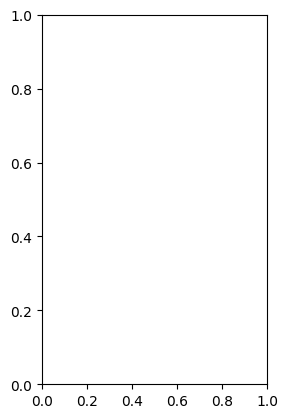

In [23]:
plt.subplot(1, 2, 1)


# 3. Plotting the Elbow Method

Text(0, 0.5, 'WCSS (Inertia)')

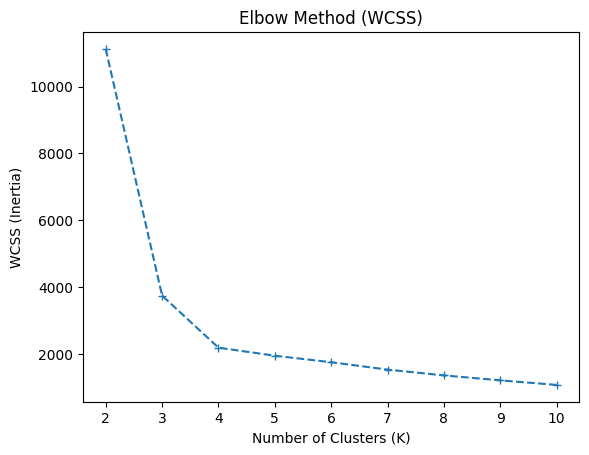

In [30]:
plt.plot(k_range, wcss[:len(k_range)], marker='+', linestyle='--')
plt.title('Elbow Method (WCSS)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')


# 4. Plotting the Silhouette Score


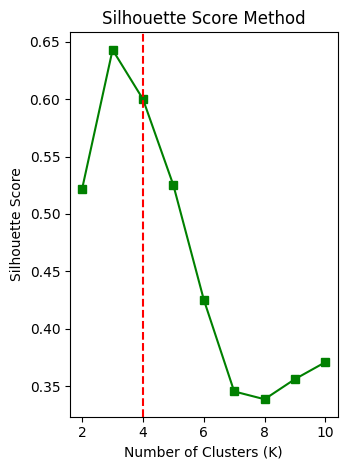

In [33]:
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='s', color='green', linestyle='-')
plt.title('Silhouette Score Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.axvline(x=4, color='red', linestyle='--') # Highlighting optimal K
plt.tight_layout()
plt.show()

# 5. Final Clustering with Optimal K (K=4)


In [34]:
optimal_k = 4
final_kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
y_kmeans = final_kmeans.fit_predict(X)


# 6. Visualize Final Clusters and Centroids


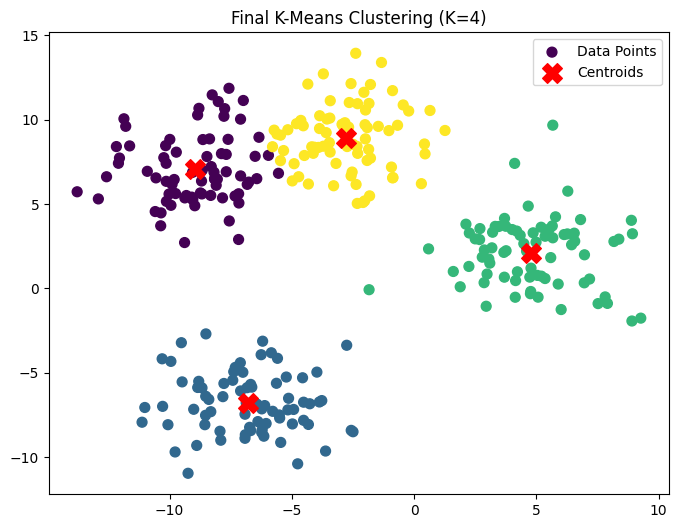

In [36]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis', label='Data Points')
plt.scatter(final_kmeans.cluster_centers_[:, 0], final_kmeans.cluster_centers_[:, 1],s=200, c='red', marker='X', label='Centroids')

plt.title(f'Final K-Means Clustering (K={optimal_k})')
plt.legend()
plt.show()

In [37]:
plt.savefig('evaluation_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

In [38]:
plt.savefig('final_clusters.png', dpi=300, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

In [39]:
%%writefile README.md
# K-Means Clustering: Elbow Method vs. Silhouette Score Analysis

## 📌 Overview
An implementation of **K-Means Clustering** in Python using `scikit-learn` on a synthetic dataset with 4 distinct centers, analyzing the difference between **WCSS (Elbow Method)** and **Silhouette Score**.

## 📊 Evaluation Metrics & The "Twist"
![Evaluation Metrics](evaluation_metrics.png)

1. **Elbow Method (WCSS):** Stabilizes significantly at **K=4**, pointing to 4 optimal clusters.
2. **Silhouette Score:** Peaks at **K=3 (~0.64)** instead of K=4 (~0.60) because two upper clusters (Purple and Yellow) are positioned closely with slight boundary overlap.

## 🎯 Final Clustering (K=4)
![Final Clusters](final_clusters.png)

## 💡 Key Takeaway
Never rely blindly on a single metric. Combining the **Elbow Method**, **Silhouette Score**, and **Visual Inspection** is essential when dealing with closely spaced clusters.

Writing README.md
